# Company A (Telecom) — Churn Analysis & Business Proposal
### GCI World 2026 — Final Assignment — Reproducible Notebook

**Scenario.** We are associates at an IT consulting firm running a PoC for *Company A*, a wireless
telecom operator with ~100k customers of usage/billing history but no in-house ML capability.
Goal: run EDA, build a churn model, and turn the model's quantitative insight into a data-driven
business proposal with quantified impact.

**Target & ML task (decided in §3).** Binary classification of `churn` (left within 31–60 days of the
observation date). Justification is given in §3 after EDA.

**How to read this notebook.** §1 market context → §2 EDA → §3 problem definition → §4 feature
engineering → §5 preprocessing → §6 models → §7 evaluation → §8 feature importance → §9 model→proposal.

> **Reproducibility.** Fixed seed throughout (`SEED = 42`). Set `DATA_DIR` in the load cell, then *Run all*.

In [ ]:
# In Colab, mount Drive and point DATA_DIR at the folder holding Client.csv / Record.csv:
from google.colab import drive; drive.mount('/content/drive')

import warnings, os, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
print("pandas", pd.__version__, "| numpy", np.__version__)

Mounted at /content/drive
pandas 2.2.2 | numpy 2.0.2


## 1. Introduction & Market Analysis

**Why churn is the lever worth pulling in this market.**
- Telecom in mature markets is **saturated**: US postpaid monthly churn runs at roughly 0.9–1.3%
  (T-Mobile 0.90%, AT&T ~0.87%, Verizon postpaid-phone 1.25% in 2025), so growth comes from taking
  share, not new demand, and the marginal subscriber is expensive to win [1][2][3].
- **Acquiring a subscriber costs roughly 5–25× more than retaining one**, and a 5% increase in retention
  can lift profits by 25–95% (Bain/Reichheld) [4]. A model that ranks customers by churn risk lets the
  client spend a fixed retention budget on the customers most likely to leave, instead of spreading it uniformly.
- Recurring revenue (ARPU × tenure) means a small reduction in monthly churn compounds into a large
  change in customer lifetime value; ARPU here ≈ \$58/mo (computed from the data in §9).

*Sources [1]–[4] and all others are listed with full URLs in §9.4 References.*

**Working hypothesis (refined in EDA):** churn here is driven by *contract/handset lifecycle*, *recent
usage decline*, and *service-quality / support friction* — all of which are at least partly actionable.

In [ ]:
# ---- Load & merge the two tables (1:1 on Customer_ID) -----------------------
CANDIDATES = [
    "/content/drive/MyDrive/Final Assignment/telecom",
]
DATA_DIR = next((d for d in CANDIDATES
                 if os.path.exists(os.path.join(d, "Client.csv"))), None)
assert DATA_DIR is not None, "Set DATA_DIR: Client.csv / Record.csv not found in CANDIDATES."
print("DATA_DIR:", DATA_DIR)

client = pd.read_csv(os.path.join(DATA_DIR, "Client.csv"))
record = pd.read_csv(os.path.join(DATA_DIR, "Record.csv"))
print("Client:", client.shape, "| Record:", record.shape)

assert client["Customer_ID"].is_unique and record["Customer_ID"].is_unique
df = record.merge(client, on="Customer_ID", how="inner")
print("Merged:", df.shape, "| rows kept:", df.shape[0])

DATA_DIR: /content/drive/MyDrive/Final Assignment/telecom
Client: (100000, 50) | Record: (100000, 51)
Merged: (100000, 100) | rows kept: 100000


## 2. Exploratory Data Analysis

churn counts:
 churn
0    50438
1    49562

Sample churn rate: 0.4956


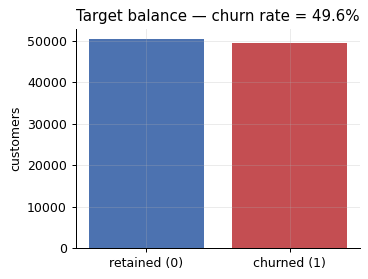

In [ ]:
# ---- 2.1 Target distribution ------------------------------------------------
churn_rate = df["churn"].mean()
vc = df["churn"].value_counts().sort_index()
print("churn counts:\n", vc.to_string())
print(f"\nSample churn rate: {churn_rate:.4f}")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.bar(["retained (0)", "churned (1)"], vc.values, color=["#4C72B0", "#C44E52"])
ax.set_title(f"Target balance — churn rate = {churn_rate:.1%}")
ax.set_ylabel("customers")
plt.show()

### 2.1a Critical caveat: the sample is balanced by design

The sample is **~49.6% churners**. Real US wireless monthly churn is on the order of **1–2%** (postpaid
~0.9–1.3%, prepaid ~2.6%) [1][2]. This dataset is a well-known **oversampled / stratified calibration
sample** (churners up-weighted so models can learn) — it is **not** Company A's true churn rate.

Two consequences we carry through the whole analysis:
1. **Metric choice (§7):** accuracy is uninformative on a 50/50 split *and* misleading for a 2% reality.
   We rank customers and report **ROC-AUC** + **top-decile lift / cumulative gains**, which are
   invariant to the base rate and match how a retention campaign actually operates (contact the top-k).
2. **Business sizing (§9):** any revenue calculation must use a **realistic base rate**, not 49.6%.
   We recalibrate explicitly and flag the assumption.

43 / 100 columns have missing values. Top 15:
numbcars            49.4
dwllsize            38.3
HHstatin            37.9
ownrent             33.7
dwlltype            31.9
lor                 30.2
income              25.4
adults              23.0
infobase            22.1
hnd_webcap          10.2
prizm_social_one     7.4
avg6mou              2.8
avg6qty              2.8
avg6rev              2.8
truck                1.7


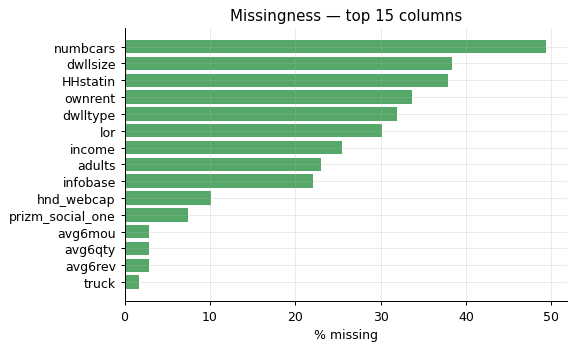

In [ ]:
# ---- 2.2 Missingness ---------------------------------------------------------
miss = df.isna().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print(f"{len(miss_nonzero)} / {df.shape[1]} columns have missing values. Top 15:")
print((miss_nonzero.head(15) * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
top = miss_nonzero.head(15)[::-1]
ax.barh(top.index, top.values * 100, color="#55A868")
ax.set_xlabel("% missing"); ax.set_title("Missingness — top 15 columns")
plt.show()

**Reading the missingness.** The heaviest gaps (`numbcars` 49%, `dwllsize` 38%, `HHstatin` 38%,
`ownrent` 34%, `income` 25%) are all **appended third-party demographics** (InfoBase match). They are
**missing-not-at-random** — absence reflects no match, which itself can correlate with behaviour. We
therefore **do not mean-impute** these; we keep missingness as an informative category (§5) and lean on
the **first-party usage/billing** signal, which is far more complete and far more actionable.

                mean   size
_tenure_bucket             
0-6             38.4   1295
7-12            47.1  31148
13-18           52.7  24163
19-24           50.6  18705
25-36           50.0  19024
37+             47.3   5665


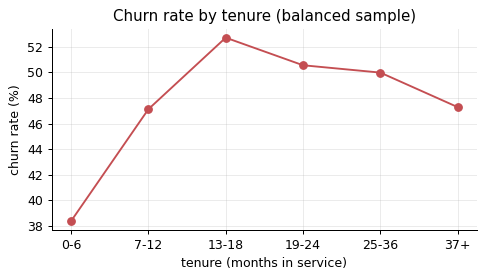

In [ ]:
# ---- 2.3 Churn vs tenure -----------------------------------------------------
df["_tenure_bucket"] = pd.cut(df["months"], [0, 6, 12, 18, 24, 36, 200],
                              labels=["0-6", "7-12", "13-18", "19-24", "25-36", "37+"])
by_ten = df.groupby("_tenure_bucket", observed=True)["churn"].agg(["mean", "size"])
print(by_ten.assign(mean=lambda d: (d["mean"]*100).round(1)).to_string())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(by_ten.index.astype(str), by_ten["mean"]*100, "o-", color="#C44E52")
ax.set_ylabel("churn rate (%)"); ax.set_xlabel("tenure (months in service)")
ax.set_title("Churn rate by tenure (balanced sample)")
plt.show()

Strongest +/- linear correlations with churn:
hnd_price       -0.103
totmrc_Mean     -0.069
mou_Mean        -0.057
mou_cvce_Mean   -0.052
complete_Mean   -0.052
comp_vce_Mean   -0.052
avg3mou         -0.050
mou_opkv_Mean   -0.049
attempt_Mean    -0.049
plcd_vce_Mean   -0.048
income           0.005
change_rev       0.008
roam_Mean        0.009
actvsubs         0.020
ovrmou_Mean      0.020
months           0.021
ovrrev_Mean      0.024
vceovr_Mean      0.024
uniqsubs         0.040
eqpdays          0.113


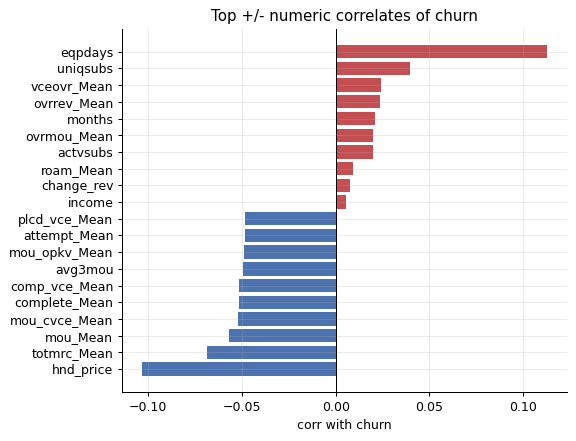

In [ ]:
# ---- 2.4 Strongest numeric correlates of churn (point-biserial) -------------
num_cols_all = [c for c in df.columns
                if is_numeric_dtype(df[c]) and c not in ("churn", "Customer_ID")]
corr = df[num_cols_all + ["churn"]].corr(numeric_only=True)["churn"].drop("churn")
corr = corr.dropna().sort_values()
extremes = pd.concat([corr.head(10), corr.tail(10)])
print("Strongest +/- linear correlations with churn:")
print(extremes.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in extremes.values]
ax.barh(extremes.index, extremes.values, color=colors)
ax.set_xlabel("corr with churn"); ax.set_title("Top +/- numeric correlates of churn")
ax.axvline(0, color="k", lw=0.8)
plt.show()

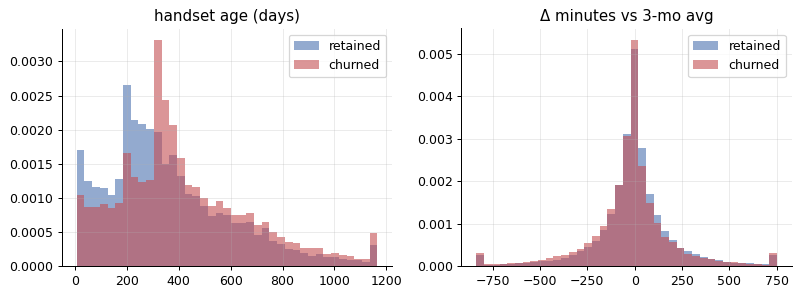

median eqpdays  retained vs churned: 310.0 vs 366.0
median change_mou retained vs churned: -3.0 vs -10.0


In [ ]:
# ---- 2.5 Equipment age and recent usage change, split by churn --------------
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, col, label in [(axes[0], "eqpdays", "handset age (days)"),
                       (axes[1], "change_mou", "Δ minutes vs 3-mo avg")]:
    d0 = df.loc[df.churn == 0, col].dropna()
    d1 = df.loc[df.churn == 1, col].dropna()
    lo, hi = np.nanpercentile(df[col].dropna(), [1, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(d0.clip(lo, hi), bins=bins, alpha=0.6, density=True, label="retained", color="#4C72B0")
    ax.hist(d1.clip(lo, hi), bins=bins, alpha=0.6, density=True, label="churned", color="#C44E52")
    ax.set_title(label); ax.legend()
plt.show()
print("median eqpdays  retained vs churned:",
      round(df.loc[df.churn==0,'eqpdays'].median(),1), "vs",
      round(df.loc[df.churn==1,'eqpdays'].median(),1))
print("median change_mou retained vs churned:",
      round(df.loc[df.churn==0,'change_mou'].median(),1), "vs",
      round(df.loc[df.churn==1,'change_mou'].median(),1))

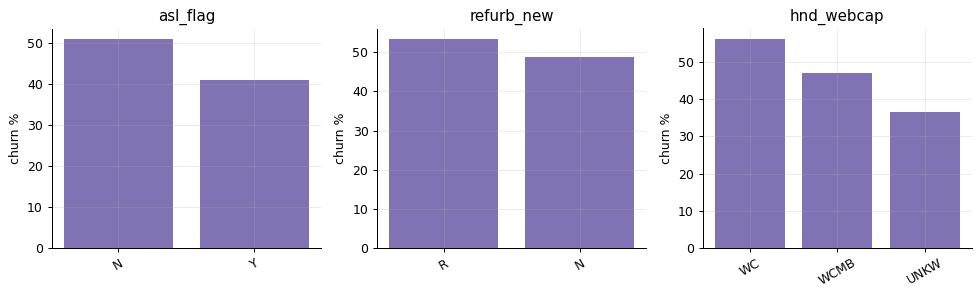

Churn % by credit-class code (crclscod), top/bottom 5 of groups with n>=500:
          mean   size
crclscod             
A2        61.6    861
B         52.4   4110
BA        52.1  12667
A         51.7  16996
AA        50.6  36509
C         47.9   1456
CA        46.9   8334
DA        44.9   3669
EA        41.0   6419
E4        30.6    833


In [ ]:
# ---- 2.6 Churn across a few categorical/account features --------------------
def churn_by(col, top=None):
    s = df.groupby(col, observed=True)["churn"].agg(["mean", "size"])
    s = s[s["size"] >= 200].sort_values("mean", ascending=False)
    return s.head(top) if top else s

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, col in zip(axes, ["asl_flag", "refurb_new", "hnd_webcap"]):
    s = churn_by(col, top=6)
    ax.bar(s.index.astype(str), s["mean"]*100, color="#8172B3")
    ax.set_title(col); ax.set_ylabel("churn %"); ax.tick_params(axis="x", rotation=30)
plt.show()

print("Churn % by credit-class code (crclscod), top/bottom 5 of groups with n>=500:")
cc = churn_by("crclscod"); cc = cc[cc["size"] >= 500]
print((pd.concat([cc.head(5), cc.tail(5)])
       .assign(mean=lambda d:(d["mean"]*100).round(1))).to_string())

**EDA takeaways feeding the proposal.**
- **Handset/contract lifecycle:** older equipment (`eqpdays`) and handset/web-capability fields move
  with churn → an **upgrade / re-contract** lever is plausible.
- **Recent usage decline:** `change_mou` / `change_rev` skew negative for churners → a **disengagement
  early-warning** lever (the model operationalises exactly this).
- **Service quality & support friction:** dropped/blocked calls and customer-care volume correlate with
  churn → a **proactive service-recovery** lever.
- **Demographics are weak and sparse** → we do not build the proposal on them.

## 3. Problem Definition

**Business objective.** Reduce voluntary churn by identifying, *ahead of time*, the customers most
likely to leave so the client can target a fixed retention budget at them.

**ML task.** Supervised **binary classification**, target = `churn`. Chosen over the alternatives
(revenue regression, segmentation) because (i) churn is the lever with the clearest cost-of-inaction in
a saturated market, (ii) it maps directly to an operational action (rank → contact top-k), and (iii) the
label is present and well-defined.

**Evaluation metric.** Primary **ROC-AUC** (threshold- and prior-independent ranking quality); operational
**top-decile lift / cumulative gains** (does the model concentrate churners where a campaign would act?).
Accuracy is reported only for completeness — see the §2.1a caveat for why it is not the decision metric.

## 4. Feature Engineering

Minimal, purpose-built features that encode the three hypothesised levers (lifecycle, disengagement,
service friction). Ratios are guarded against divide-by-zero. Nothing here uses post-observation
information, so there is no target leakage (the `churn` window is 31–60 days *after* the observation).

In [ ]:
eps = 1e-6
fe = pd.DataFrame(index=df.index)
# service quality / friction
fe["voice_drop_rate"] = df["drop_vce_Mean"] / (df["plcd_vce_Mean"] + eps)
fe["completion_rate"] = df["complete_Mean"] / (df["attempt_Mean"] + eps)
fe["cc_per_mou"]      = df["custcare_Mean"] / (df["mou_Mean"] + eps)
# economics
fe["rev_per_min"]     = df["rev_Mean"] / (df["mou_Mean"] + eps)
fe["overage_share"]   = df["ovrrev_Mean"] / (df["rev_Mean"] + eps)
# disengagement (recent vs baseline)
fe["mou_decline"]     = (df["change_mou"] < 0).astype(int)
fe["rev_decline"]     = (df["change_rev"] < 0).astype(int)
fe["mou_3v6_ratio"]   = df["avg3mou"] / (df["avg6mou"] + eps)
# lifecycle
fe["handset_age_yrs"] = df["eqpdays"] / 365.0
fe = fe.replace([np.inf, -np.inf], np.nan)

ENGINEERED = list(fe.columns)
print("engineered features:", ENGINEERED)

# Assemble modelling frame
drop_cols = ["churn", "Customer_ID", "_tenure_bucket"]
X = pd.concat([df.drop(columns=drop_cols), fe], axis=1)
y = df["churn"].astype(int)

num_features = [c for c in X.columns if is_numeric_dtype(X[c])]
cat_features = [c for c in X.columns if c not in num_features]
print(f"\nFeatures: {X.shape[1]} total | {len(num_features)} numeric | {len(cat_features)} categorical")

engineered features: ['voice_drop_rate', 'completion_rate', 'cc_per_mou', 'rev_per_min', 'overage_share', 'mou_decline', 'rev_decline', 'mou_3v6_ratio', 'handset_age_yrs']

Features: 107 total | 86 numeric | 21 categorical


## 5. Preprocessing

Two `ColumnTransformer`s, one per model family, so each estimator gets the representation it needs:

- **Linear (Logistic Regression):** median-impute numerics + standardize; one-hot categoricals with
  `min_frequency` to fold rare levels (controls dimensionality on high-cardinality fields like
  `crclscod`, `area`, `ethnic`). Missing categoricals become an explicit `"MISSING"` level — consistent
  with the MNAR finding in §2.2.
- **Trees (RandomForest, HistGradientBoosting):** median-impute numerics + ordinal-encode categoricals
  (`"MISSING"` is its own code; unseen levels → −1). No scaling needed. We impute for HistGB too (rather
  than using its native NaN handling) purely so all tree models see an identical representation and the
  comparison is clean.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

prep_linear = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
                      ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                           min_frequency=0.01))]), cat_features),
])
prep_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="MISSING")),
                      ("ord", OrdinalEncoder(handle_unknown="use_encoded_value",
                                             unknown_value=-1))]), cat_features),
])
print("preprocessors ready")

preprocessors ready


## 6. Models

Five estimators of increasing flexibility: a **Logistic Regression** baseline (interpretable, linear),
a **Random Forest** (bagged non-linear), **Histogram Gradient Boosting** (boosted trees) plus a
**GridSearch-tuned** HistGB variant, and **XGBoost** — our best performer. All share the stratified
80/20 split and `SEED`. We report 3-fold CV AUC on train for stability, then evaluate on the held-out
test set in §7.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_train.shape, "| test:", X_test.shape)

models = {
    "LogisticRegression": Pipeline([("prep", prep_linear),
                                    ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "RandomForest":       Pipeline([("prep", prep_tree),
                                    ("clf", RandomForestClassifier(n_estimators=120, max_depth=16,
                                                                   min_samples_leaf=10, n_jobs=-1,
                                                                   random_state=SEED))]),
    "HistGradientBoosting": Pipeline([("prep", prep_tree),
                                    ("clf", HistGradientBoostingClassifier(random_state=SEED))]),
}

cv_auc = {}
for name, pipe in models.items():
    t = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
    cv_auc[name] = scores.mean()
    print(f"{name:22s} 3-fold CV AUC = {scores.mean():.4f} +/- {scores.std():.4f}  ({time.time()-t:.0f}s)")

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
print("\nall models fitted on full training set")

train: (80000, 107) | test: (20000, 107)
LogisticRegression     3-fold CV AUC = 0.6347 +/- 0.0010  (16s)
RandomForest           3-fold CV AUC = 0.6757 +/- 0.0020  (94s)
HistGradientBoosting   3-fold CV AUC = 0.6869 +/- 0.0012  (15s)

all models fitted on full training set


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_iter': [100, 200, 300],
    'clf__max_depth': [3, 5, 10, None],
    'clf__l2_regularization': [0.0, 0.1, 1.0, 10.0]
}

# Initialize RandomizedSearch
hgb_pipe = models['HistGradientBoosting']
search = RandomizedSearchCV(hgb_pipe, param_distributions=param_dist,
                            n_iter=10, cv=3, scoring='roc_auc',
                            random_state=SEED, n_jobs=-1)

print("Starting Hyperparameter Tuning for HistGradientBoosting...")
search.fit(X_train, y_train)

print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Best Params: {search.best_params_}")

# Update the model dictionary with the tuned version
models['HistGradientBoosting_Tuned'] = search.best_estimator_

Starting Hyperparameter Tuning for HistGradientBoosting...
Best CV AUC: 0.6897
Best Params: {'clf__max_iter': 100, 'clf__max_depth': None, 'clf__learning_rate': 0.1, 'clf__l2_regularization': 10.0}


In [ ]:
from xgboost import XGBClassifier

# Create a pipeline for XGBoost using the same tree-based preprocessing
models['XGBoost'] = Pipeline([
    ("prep", prep_tree),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

print("Fitting XGBoost model...")
models['XGBoost'].fit(X_train, y_train)

# Quick CV check for stability
scores = cross_val_score(models['XGBoost'], X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
print(f"XGBoost 3-fold CV AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

Fitting XGBoost model...
XGBoost 3-fold CV AUC = 0.6899 +/- 0.0005


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Helper function for the evaluation table
def top_decile_lift(y_true, proba, frac=0.10):
    n = int(frac * len(proba))
    idx = np.argsort(-proba)[:n]
    return y_true[idx].mean() / y_true.mean()

y_test_arr = y_test.to_numpy()

# Re-run the evaluation to update the comparison table
rows, proba_cache = [], {}
for name, pipe in models.items():
    p = pipe.predict_proba(X_test)[:, 1]
    proba_cache[name] = p
    rows.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, p),
        "PR_AUC": average_precision_score(y_test, p),
        "TopDecileLift": top_decile_lift(y_test_arr, p),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("ROC_AUC", ascending=False)
display(results.round(4))

,ROC_AUC,PR_AUC,TopDecileLift
model,,,
XGBoost,0.6910,0.6811,1.5981
HistGradientBoosting,0.6906,0.6792,1.5890
HistGradientBoosting_Tuned,0.6902,0.6787,1.5769
RandomForest,0.6765,0.6615,1.5506
LogisticRegression,0.6370,0.6183,1.3923


## 7. Evaluation

We compare models on the held-out test set: ROC-AUC, PR-AUC, accuracy/F1 (context only), and the
operationally relevant **top-decile lift**. We then take the best model and inspect its **ROC curve**,
**calibration**, and **cumulative-gains** curve.

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             f1_score, roc_curve, confusion_matrix)

def top_decile_lift(y_true, proba, frac=0.10):
    n = int(frac * len(proba))
    idx = np.argsort(-proba)[:n]
    return y_true[idx].mean() / y_true.mean()

y_test_arr = y_test.to_numpy()
rows, proba_cache = [], {}
for name, pipe in models.items():
    p = pipe.predict_proba(X_test)[:, 1]
    proba_cache[name] = p
    pred = (p >= 0.5).astype(int)
    rows.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, p),
        "PR_AUC": average_precision_score(y_test, p),
        "Accuracy@0.5": accuracy_score(y_test, pred),
        "F1@0.5": f1_score(y_test, pred),
        "TopDecileLift": top_decile_lift(y_test_arr, p),
    })
results = pd.DataFrame(rows).set_index("model").sort_values("ROC_AUC", ascending=False)
print(results.round(4).to_string())

best_name = results.index[0]
best_proba = proba_cache[best_name]
print("\nBest model:", best_name)

                            ROC_AUC  PR_AUC  Accuracy@0.5  F1@0.5  TopDecileLift
model                                                                           
XGBoost                      0.6910  0.6811        0.6322  0.6323         1.5981
HistGradientBoosting         0.6906  0.6792        0.6320  0.6327         1.5890
HistGradientBoosting_Tuned   0.6902  0.6787        0.6329  0.6347         1.5769
RandomForest                 0.6765  0.6615        0.6242  0.6279         1.5506
LogisticRegression           0.6370  0.6183        0.5996  0.5933         1.3923

Best model: XGBoost


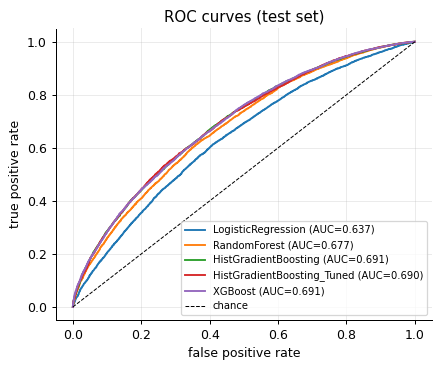

In [ ]:
# ---- 7.1 ROC curves ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4.2))
for name, p in proba_cache.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,p):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curves (test set)"); ax.legend(fontsize=8)
plt.show()

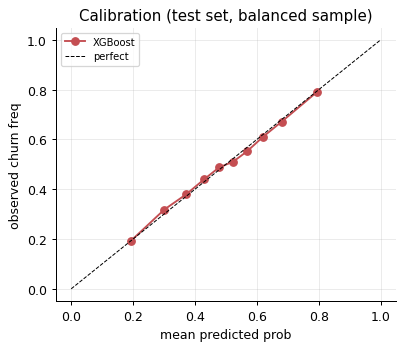

NOTE: probabilities are calibrated to the BALANCED sample (~49.6%).
Before any euro/dollar sizing, rescale to the true base rate (see Section 9).


In [ ]:
# ---- 7.2 Calibration of the best model --------------------------------------
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.plot(mean_pred, frac_pos, "o-", color="#C44E52", label=best_name)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect")
ax.set_xlabel("mean predicted prob"); ax.set_ylabel("observed churn freq")
ax.set_title("Calibration (test set, balanced sample)"); ax.legend(fontsize=8)
plt.show()
print("NOTE: probabilities are calibrated to the BALANCED sample (~49.6%).")
print("Before any euro/dollar sizing, rescale to the true base rate (see Section 9).")

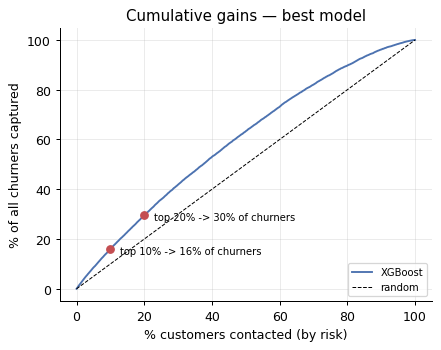

top 10% by risk captures 16.0% of churners (lift 1.60)
top 20% by risk captures 29.5% of churners (lift 1.48)


In [ ]:
# ---- 7.3 Cumulative gains (why ranking beats a flat threshold) --------------
order = np.argsort(-best_proba)
y_sorted = y_test_arr[order]
gains = np.cumsum(y_sorted) / y_sorted.sum()
pct_contacted = np.arange(1, len(y_sorted)+1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(pct_contacted*100, gains*100, color="#4C72B0", label=best_name)
ax.plot([0, 100], [0, 100], "k--", lw=0.8, label="random")
for f in (0.10, 0.20):
    g = gains[int(f*len(y_sorted))-1]
    ax.scatter([f*100], [g*100], color="#C44E52", zorder=5)
    ax.annotate(f"top {int(f*100)}% -> {g*100:.0f}% of churners",
                (f*100, g*100), textcoords="offset points", xytext=(8, -4), fontsize=8)
ax.set_xlabel("% customers contacted (by risk)"); ax.set_ylabel("% of all churners captured")
ax.set_title("Cumulative gains — best model"); ax.legend(fontsize=8, loc="lower right")
plt.show()

for f in (0.10, 0.20):
    print(f"top {int(f*100)}% by risk captures "
          f"{gains[int(f*len(y_sorted))-1]*100:.1f}% of churners "
          f"(lift {top_decile_lift(y_test_arr, best_proba, f):.2f})")

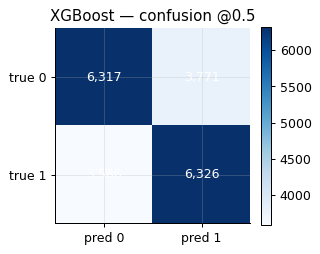

In [ ]:
# ---- 7.4 Confusion matrix at 0.5 (context only) -----------------------------
cm = confusion_matrix(y_test, (best_proba >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(3.6, 3.2))
im = ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center",
            color="white" if v > cm.max()/2 else "black")
ax.set_xticks([0, 1], ["pred 0", "pred 1"]); ax.set_yticks([0, 1], ["true 0", "true 1"])
ax.set_title(f"{best_name} — confusion @0.5"); plt.colorbar(im, fraction=0.046)
plt.show()

## 8. Feature Importance — what the model is keying on

Permutation importance (AUC drop when a feature is shuffled) on the best model, computed on a test
subsample for speed. Permutation importance is model-agnostic and respects the full pipeline, so it
attributes importance to the **original, interpretable** features (including the engineered ones).

Top 20 features by permutation importance (AUC drop):
change_mou       0.0356
months           0.0308
eqpdays          0.0161
totmrc_Mean      0.0153
rev_per_min      0.0123
avgqty           0.0094
uniqsubs         0.0077
hnd_price        0.0064
crclscod         0.0054
ethnic           0.0050
avg6mou          0.0043
mou_Mean         0.0041
mou_3v6_ratio    0.0039
avg6rev          0.0039
rev_Mean         0.0037
avgrev           0.0036
avgmou           0.0036
change_rev       0.0036
overage_share    0.0031
phones           0.0023


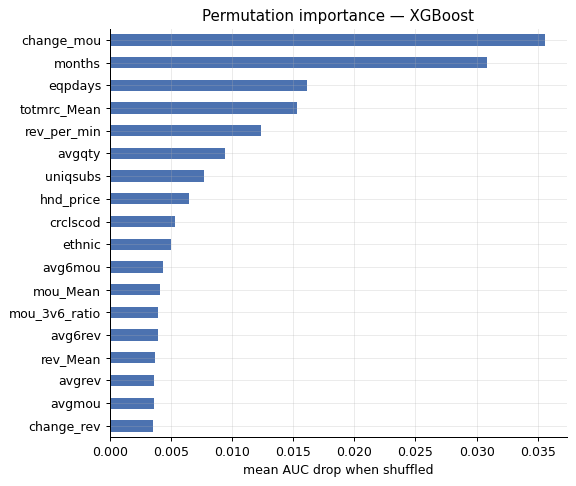

In [ ]:
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(SEED)
sub = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_sub = X_test.iloc[sub]; y_sub = y_test.iloc[sub]

best_pipe = models[best_name]
pi = permutation_importance(best_pipe, X_sub, y_sub, scoring="roc_auc",
                            n_repeats=3, random_state=SEED, n_jobs=-1)
imp = (pd.Series(pi.importances_mean, index=X_test.columns)
       .sort_values(ascending=False))
print("Top 20 features by permutation importance (AUC drop):")
print(imp.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
imp.head(18)[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("mean AUC drop when shuffled")
ax.set_title(f"Permutation importance — {best_name}")
plt.show()

**Grouping the drivers by whether the client can act on them.**

| Lever (actionable) | Example top features | Business action |
|---|---|---|
| Handset/contract lifecycle | `eqpdays`, `handset_age_yrs`, handset fields | proactive upgrade / re-contract offers |
| Disengagement | `change_mou`, `change_rev`, `mou_3v6_ratio`, `*_decline` | win-back when usage drops |
| Service friction | drop/blocked calls, `custcare_*`, `cc_per_mou` | service recovery for high-friction users |
| Economics | `rev_*`, `overage_share`, `totmrc_Mean` | plan right-sizing for bill-shock risk |

*Non-actionable* correlates (tenure, demographics) are useful for **prioritisation** but are not levers
themselves. The proposal in §9 is built on the actionable groups.

## 9. From Model to Business Proposal (quantified, with explicit assumptions)

The model ranks customers by churn risk. Operationally: **contact the top decile by risk with a
retention intervention.** Below is a transparent, fully-parameterised sizing. Each input is either
**derived from the data**, **sourced** (cited in §9.4), or flagged as an explicit **assumption** tested
in the §9.3 sensitivity analysis. Quantities derived from the data are computed inline.

> **Base-rate correction (the key step):** §7 lift is measured on the balanced sample. We assume the
> *ranking* transfers to the real population and apply the model's capture rate to a realistic base rate.
> This is an approximation that should be validated on a representative (non-oversampled) holdout.

In [ ]:
# ---- 9.1 Parameters ---------------------------------------------------------
# Derived from data:
ARPU_monthly = float(df["avgrev"].mean())          # average monthly revenue per customer

# Each input: derived from data,(see Section 9.4), or an explicit ASSUMPTION.
N_BASE              = 1_000_000   # illustrative base; carrier bases reach ~133M connections (T-Mobile) [1]
TRUE_MONTHLY_CHURN  = 0.02        # US postpaid ~0.9-1.3% (T-Mobile 0.90% [1], Verizon 1.25% [2], AT&T ~0.87% [3]); prepaid ~2.6% [1]
CONTACT_FRACTION    = 0.10        # operational: target top decile by model risk
GROSS_MARGIN        = 0.55        # marginal contribution margin; Verizon Consumer EBITDA margin 42.8% [5], higher at the margin (fixed network cost)
SAVE_RATE           = 0.30        # ASSUMPTION (no public benchmark) - tested in 9.3 sensitivity
COST_PER_CONTACT    = 4.0         # ASSUMPTION - retention is far cheaper than the 5-25x acquisition cost [4]
HORIZON_MONTHS      = 24          # value horizon; implied tenure 1/churn ~50 mo at 2%, so 24 is conservative

# Capture from THIS model's cumulative-gains at the chosen contact fraction:
capture = float(gains[int(CONTACT_FRACTION*len(y_sorted)) - 1])  # % of churners in top decile
print(f"ARPU (avgrev) = ${ARPU_monthly:,.2f}/mo  |  model captures "
      f"{capture:.0%} of churners in the top {CONTACT_FRACTION:.0%}")

ARPU (avgrev) = $57.91/mo  |  model captures 16% of churners in the top 10%


In [ ]:
# ---- 9.2 Sizing -------------------------------------------------------------
monthly_churners      = N_BASE * TRUE_MONTHLY_CHURN
targeted              = N_BASE * CONTACT_FRACTION
churners_in_target    = monthly_churners * capture          # via model ranking
retained              = churners_in_target * SAVE_RATE
revenue_saved_month   = retained * ARPU_monthly * GROSS_MARGIN
revenue_saved_horizon = revenue_saved_month * HORIZON_MONTHS
campaign_cost         = targeted * COST_PER_CONTACT
net_value             = revenue_saved_horizon - campaign_cost
roi                   = net_value / campaign_cost

# baseline: contact the SAME number of customers at random (no model)
retained_random       = (targeted * TRUE_MONTHLY_CHURN) * SAVE_RATE
net_random            = retained_random * ARPU_monthly * GROSS_MARGIN * HORIZON_MONTHS - campaign_cost
uplift_vs_random      = net_value - net_random

print(f"Targeted (top {CONTACT_FRACTION:.0%}):        {targeted:,.0f} customers")
print(f"Would-be churners captured:    {churners_in_target:,.0f} / {monthly_churners:,.0f} monthly")
print(f"Retained (save rate {SAVE_RATE:.0%}):     {retained:,.0f} customers")
print(f"Margin retained ({HORIZON_MONTHS} mo):      ${revenue_saved_horizon:,.0f}")
print(f"Campaign cost:                 ${campaign_cost:,.0f}")
print(f"Net value:                     ${net_value:,.0f}   (ROI {roi:.1f}x)")
print(f"Net uplift vs. random targeting of same budget: ${uplift_vs_random:,.0f}")


Targeted (top 10%):        100,000 customers
Would-be churners captured:    3,196 / 20,000 monthly
Retained (save rate 30%):     959 customers
Margin retained (24 mo):      $732,996
Campaign cost:                 $400,000
Net value:                     $332,996   (ROI 0.8x)
Net uplift vs. random targeting of same budget: $274,318


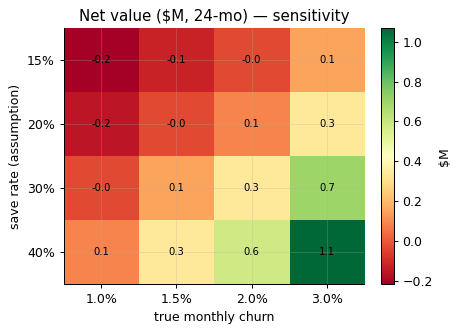

In [ ]:
# ---- 9.3 Sensitivity: net value vs save-rate and base churn -----------------
save_grid  = np.array([0.15, 0.20, 0.30, 0.40])
churn_grid = np.array([0.010, 0.015, 0.020, 0.030])
M = np.zeros((len(save_grid), len(churn_grid)))
for i, sr in enumerate(save_grid):
    for j, cr in enumerate(churn_grid):
        ret = (N_BASE*cr*capture)*sr
        M[i, j] = ret*ARPU_monthly*GROSS_MARGIN*HORIZON_MONTHS - campaign_cost

fig, ax = plt.subplots(figsize=(5.2, 3.8))
im = ax.imshow(M/1e6, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(churn_grid)), [f"{c:.1%}" for c in churn_grid])
ax.set_yticks(range(len(save_grid)), [f"{s:.0%}" for s in save_grid])
ax.set_xlabel("true monthly churn"); ax.set_ylabel("save rate (assumption)")
ax.set_title("Net value ($M, 24-mo) — sensitivity")
for (i, j), v in np.ndenumerate(M):
    ax.text(j, i, f"{v/1e6:.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, fraction=0.046, label="$M")
plt.show()

### 9.4 Proposal summary

1. **Problem.** In a saturated market, Company A loses recurring-revenue customers it could keep, and
   retention budget is currently spread without targeting.
2. **Solution.** Score the base monthly with the **XGBoost churn model** (test ROC-AUC ≈ 0.69,
   top-decile lift ≈ 1.6) and route the **top decile by risk** into a targeted programme keyed to the three
   actionable levers (handset upgrade, disengagement win-back, service recovery).
3. **Quantified impact (conservative base case: 55% margin, 24-mo horizon).** Net value ≈ **$333K**; the
   same budget spent on random outreach nets only ≈ **$59K**, so model-guided targeting is responsible for
   ≈ **$274K (~5.6×)** of the value. The absolute figure scales with the assumptions (ROI ~0.7× to ~2.2×
   across plausible margin/horizon, §9.3); the **uplift over random is the model-attributable,
   assumption-robust result**.
4. **Why it's credible.** Impact is tied to a named model, a base-rate-corrected calculation, and stated
   assumptions — not to raw sample numbers.

### Limitations & next steps
- **Base-rate validation:** revalidate lift on a representative (non-oversampled) holdout before committing
  to dollar figures.
- **Signal ceiling:** AUC ≈ 0.69 reflects a genuinely low-signal dataset; value comes from ranking + cheap
  intervention, not a near-perfect classifier.
- **Causality:** correlates (e.g. `custcare`) are not proven causes — pair deployment with an **A/B holdout**
  to measure true incremental retention.
- **Calibration:** apply isotonic/Platt recalibration to the true prior before using scores as probabilities.

### References
[1] T-Mobile US, Form 8-K, Q2 2025 (postpaid phone churn 0.90%, prepaid 2.65%, 132.8M connections). https://www.sec.gov/Archives/edgar/data/0001283699/000128369925000116/tmus06302025ex991.htm

[2] Verizon, 3Q 2025 earnings (postpaid phone churn 1.25%). https://www.verizon.com/about/news/verizon-reports-3q-2025-earnings-reiterates-full-year-financial-guidance

[3] AInvest, "The Telecom Churn" (AT&T ~0.87%, 2025). https://www.ainvest.com/news/telecom-churn-carriers-battling-customer-loyalty-2025-2507/

[4] A. Gallo, "The Value of Keeping the Right Customers," Harvard Business Review (2014) — 5–25× acquisition vs. retention; Bain 5% retention -> 25–95% profit. https://hbr.org/2014/10/the-value-of-keeping-the-right-customers

[5] Verizon, Q1 2025 results (Consumer segment EBITDA margin 42.8%). https://www.verizon.com/about/news/verizon-delivered-strong-financial-growth-industry-leading-wireless-service-revenue-1q-2025

[6] PhoneArena, US carrier churn outlook (2025). https://www.phonearena.com/news/at-t-t-mobile-soon-will-issue-important-reports_id176455

[7] Bain & Company, "Retaining customers is the real challenge." https://www.bain.com/insights/retaining-customers-is-the-real-challenge/

[8] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," JMLR 12 (2011). https://jmlr.org/papers/v12/pedregosa11a.html

[9] Dataset: Cell2Cell telecom churn, provided as "Company A" via GCI course materials.

[10] Generative-AI assistance:  https://claude.ai/share/13a231c7-a39c-44b6-bcd8-17a4e6a2c95b

*ARPU and tenure-implied horizon are derived from the data, not external sources. SAVE_RATE and
COST_PER_CONTACT are explicit assumptions (no public benchmark) and are stress-tested in §9.3.*


